# Einstein's Mission

Einstein Bannerjee is the name of a fictional character.

He will use artificial intelligence together with humanity's accumulated astronomical knowledge to discover, understand, and document interesting objects in the Universe.

Section 1 — Introduction (Markdown)

# Notebook 21 — Comparative Galaxy Analysis

## Purpose

In the previous notebooks, Einstein identified and characterized an individual galaxy detected in the Hubble eXtreme Deep Field (XDF). Measurements from image analysis were combined with cross-matches to SIMBAD and the NASA/IPAC Extragalactic Database (NED) to determine the galaxy's position, classification, and physical properties.

This notebook extends that work by placing the target galaxy into its broader astronomical context. Rather than studying a single object in isolation, we construct a comparison sample of galaxies with similar positions and redshifts using the CDS TAP (Table Access Protocol) service and the GOODS-MUSIC survey catalog.

## Scientific Objectives

The objectives of this notebook are to:

- Retrieve galaxies from a deep extragalactic survey using ADQL and TAP.
- Construct a comparison sample centered on the target galaxy.
- Prefer spectroscopic redshifts where available while using photometric redshifts to improve completeness.
- Explore the statistical properties of the comparison sample.
- Produce a reusable dataset for subsequent analyses of galaxy evolution and population studies.

## Data Sources

This notebook combines information from several resources:

- Einstein master catalog generated in previous notebooks
- GOODS-MUSIC multiwavelength galaxy catalog
- CDS TAPVizieR service
- Astropy and PyVO for astronomical data access

## Methodology

The workflow consists of four stages:

1. Load the target galaxy identified in previous notebooks.
2. Query the GOODS-MUSIC catalog using ADQL through the CDS TAP service.
3. Select galaxies within a defined spatial radius and redshift interval.
4. Save the resulting comparison sample for downstream scientific analysis.

## Expected Outcome

The primary output of this notebook is a scientifically motivated comparison sample of galaxies surrounding the target object. This sample forms the basis for future notebooks investigating galaxy environments, photometric properties, morphology, and evolutionary trends.

---

*Cosmic Intelligence Lab – Einstein Research Series*

# ==========================================
# Cell 2 — Imports
# ==========================================

import numpy as np

from astropy.table import Table

In [3]:
# ==========================================
# Cell 3 — Load the Target Galaxy
# ==========================================

from astropy.table import Table

# Path to the Einstein master catalog
catalog_file = "../data/catalogs/einstein_master_catalog.ecsv"

# Load the catalog
catalog = Table.read(catalog_file, format="ascii.ecsv")

# Select the target galaxy
target_id = 39
target = catalog[catalog["label"] == target_id][0]

# Coordinates from the Einstein catalog
target_ra = float(target["ra_deg"])
target_dec = float(target["dec_deg"])

# Properties established in Notebook 20
target_name = "EIS J033238.61-274631.6"
target_type = "Galaxy"
target_z = 0.621743

print("=" * 50)
print("Target Galaxy")
print("=" * 50)
print(f"Einstein Label : {target_id}")
print(f"Catalog Name   : {target_name}")
print(f"Object Type    : {target_type}")
print(f"Redshift       : {target_z:.6f}")
print(f"RA             : {target_ra:.6f} deg")
print(f"Dec            : {target_dec:.6f} deg")

Target Galaxy
Einstein Label : 39
Catalog Name   : EIS J033238.61-274631.6
Object Type    : Galaxy
Redshift       : 0.621743
RA             : 53.160803 deg
Dec            : -27.775437 deg


In [4]:
# ==========================================
# Cell 4 — Connect to the CDS TAP Service
# ==========================================

from pyvo.dal import TAPService

# CDS TAP service (VizieR)
tap = TAPService(
    "https://tapvizier.cds.unistra.fr/TAPVizieR/tap"
)

print("Connected to CDS TAP service.")
print(f"Endpoint: {tap.baseurl}")

Connected to CDS TAP service.
Endpoint: https://tapvizier.cds.unistra.fr/TAPVizieR/tap


In [5]:
# ==========================================
# Cell 5 — Define Search Parameters
# ==========================================

# GOODS-MUSIC catalog available through CDS TAP
catalog_name = "J/A+A/449/951/goods"

# Search radius around the target galaxy
radius = 0.01        # degrees (≈36 arcseconds)

# Redshift window for comparison galaxies
delta_z = 0.05

print("=" * 50)
print("Comparison Sample Parameters")
print("=" * 50)
print(f"Catalog          : {catalog_name}")
print(f"Target Redshift  : {target_z:.6f}")
print(f"Δz               : ±{delta_z:.3f}")
print(f"Search Radius    : {radius:.3f} deg ({radius*3600:.0f} arcsec)")

Comparison Sample Parameters
Catalog          : J/A+A/449/951/goods
Target Redshift  : 0.621743
Δz               : ±0.050
Search Radius    : 0.010 deg (36 arcsec)


In [6]:
# ==========================================
# Cell 6 — Query the GOODS-MUSIC Catalog
# ==========================================

query = f"""
SELECT *
FROM "{catalog_name}"
WHERE
    CONTAINS(
        POINT('ICRS', RAJ2000, DEJ2000),
        CIRCLE('ICRS', {target_ra}, {target_dec}, {radius})
    ) = 1
"""

print("=" * 50)
print("Submitting ADQL Query...")
print("=" * 50)

job = tap.submit_job(query)
job.run()
job.wait()

results = job.fetch_result()

# Convert the TAP results into an Astropy Table
goods = results.to_table()

print(f"Retrieved {len(goods)} objects.")

Submitting ADQL Query...
Retrieved 120 objects.


In [7]:
# ==========================================
# Cell 7 — Inspect GOODS-MUSIC table
# ==========================================

print("=" * 50)
print("GOODS-MUSIC Table")
print("=" * 50)

print(f"Number of objects: {len(goods)}")
print()

print("Columns:")
for col in goods.colnames:
    print(f"  {col}")

print()
print("=" * 50)
print("First Five Objects")
print("=" * 50)

goods[:5]

GOODS-MUSIC Table
Number of objects: 120

Columns:
  Seq
  RAJ2000
  DEJ2000
  zspec
  q_zspec
  SpClass
  r_SpClass
  zphot
  POS
  star
  AGN
  zlim
  kslim
  S/G
  l_U35mag
  U35mag
  l_U38mag
  U38mag
  l_UVIMmag
  UVIMmag
  l_Bmag
  Bmag
  l_Vmag
  Vmag
  l_imag
  imag
  l_zmag
  zmag
  e_U35mag
  e_U38mag
  e_UVIMmag
  e_Bmag
  e_Vmag
  e_imag
  e_zmag
  l_Jmag
  Jmag
  e_Jmag
  l_Hmag
  Hmag
  e_Hmag
  l_Ksmag
  Ksmag
  e_Ksmag
  l_IR36mag
  IR36mag
  e_IR36mag
  l_IR45mag
  IR45mag
  e_IR45mag
  l_IR58mag
  IR58mag
  e_IR58mag
  l_IR80mag
  IR80mag
  e_IR80mag

First Five Objects


Seq,RAJ2000,DEJ2000,zspec,q_zspec,SpClass,r_SpClass,zphot,POS,star,AGN,zlim,kslim,S/G,l_U35mag,U35mag,l_U38mag,U38mag,l_UVIMmag,UVIMmag,l_Bmag,Bmag,l_Vmag,Vmag,l_imag,imag,l_zmag,zmag,e_U35mag,e_U38mag,e_UVIMmag,e_Bmag,e_Vmag,e_imag,e_zmag,l_Jmag,Jmag,e_Jmag,l_Hmag,Hmag,e_Hmag,l_Ksmag,Ksmag,e_Ksmag,l_IR36mag,IR36mag,e_IR36mag,l_IR45mag,IR45mag,e_IR45mag,l_IR58mag,IR58mag,e_IR58mag,l_IR80mag,IR80mag,e_IR80mag
,deg,deg,,,,,,,,,,mag,,,mag,,mag,,mag,,mag,,mag,,mag,,mag,mag,mag,mag,mag,mag,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag,,mag,mag
int32,float64,float64,float64,int16,object,object,float64,int16,int16,int16,float64,float64,float64,str1,float64,str1,float64,str1,float64,str1,float64,str1,float64,str1,float64,str1,float64,float64,float64,float64,float64,float64,float64,float64,str1,float64,float64,str1,float64,float64,str1,float64,float64,str1,float64,float64,str1,float64,float64,str1,float64,float64,str1,float64,float64
10600,53.165882,-27.781542,--,--,UNKNOWN,UNKNOWN,1.01,1,0,0,28.034,27.003,0.03,,24.682,,24.292,,--,,24.656,,24.028,,23.333,,22.839,0.075,0.144,--,0.04,0.019,0.02,0.015,,22.398,0.023,,22.114,0.028,,21.663,0.02,,21.468,0.016,,21.661,0.02,,22.185,0.083,,22.412,0.1
10607,53.167957,-27.782011,--,--,UNKNOWN,UNKNOWN,2.93,1,0,0,28.027,27.001,0.09,,27.429,<,26.546,,--,,27.134,,26.236,,26.172,,26.023,0.482,1.086,--,0.099,0.057,0.104,0.122,,26.138,0.444,,25.262,0.368,,25.132,0.284,,25.139,0.245,,25.142,0.386,<,24.367,1.086,<,24.364,1.086
10662,53.168278,-27.781055,--,--,UNKNOWN,UNKNOWN,2.96,1,0,0,28.03,26.997,0.13,,27.602,<,26.546,,--,,26.162,,25.697,,25.808,,25.845,0.652,1.086,--,0.048,0.029,0.069,0.087,,25.698,0.242,,26.004,0.552,,26.16,0.737,,26.156,0.415,<,26.016,1.086,<,24.544,1.086,<,24.541,1.086
10716,53.168545,-27.780523,--,--,UNKNOWN,UNKNOWN,2.76,1,0,0,28.033,26.999,0.88,<,27.787,,25.583,,--,,26.833,,26.639,,26.714,,27.108,1.086,0.388,--,0.05,0.039,0.078,0.13,,25.958,0.368,<,25.469,1.086,<,25.329,1.086,<,25.807,1.086,<,25.271,1.086,<,23.798,1.086,<,23.795,1.086
10743,53.169388,-27.780155,--,--,UNKNOWN,UNKNOWN,1.09,1,0,0,28.035,26.999,0.01,<,27.843,,26.348,,--,,26.757,,26.701,,26.341,,25.891,1.086,0.687,--,0.103,0.078,0.133,0.11,,26.047,0.366,,25.928,0.577,,25.588,0.357,,25.597,0.371,,26.016,0.959,<,24.544,1.086,<,24.541,1.086


In [8]:
# ==========================================
# Cell 8 — Build the Comparison Sample
# ==========================================

import numpy as np
from astropy.table import Table

# Make a working copy
comparison = goods.copy()

# Best available redshift:
# Prefer spectroscopic; otherwise use photometric.
best_z = []

for row in comparison:
    if np.ma.is_masked(row["zspec"]):
        best_z.append(row["zphot"])
    else:
        best_z.append(float(row["zspec"]))

comparison["best_z"] = best_z

# Keep galaxies within the chosen redshift window
comparison = comparison[
    np.abs(comparison["best_z"] - target_z) <= delta_z
]

print("=" * 50)
print("Comparison Sample")
print("=" * 50)
print(f"Galaxies within Δz = ±{delta_z:.3f}: {len(comparison)}")

Comparison Sample
Galaxies within Δz = ±0.050: 13


In [9]:
# ==========================================
# Cell 9 — Compute Angular Separations
# ==========================================

from astropy.coordinates import SkyCoord
import astropy.units as u

# Target coordinate
target_coord = SkyCoord(
    ra=target_ra * u.deg,
    dec=target_dec * u.deg,
    frame="icrs"
)

# GOODS-MUSIC coordinates already have units
comparison_coords = SkyCoord(
    ra=comparison["RAJ2000"],
    dec=comparison["DEJ2000"],
    frame="icrs"
)

# Compute angular separations
comparison["sep_arcsec"] = (
    target_coord.separation(comparison_coords)
    .to(u.arcsec)
    .value
)

# Sort by proximity
comparison.sort("sep_arcsec")

print("=" * 50)
print("Nearest Comparison Galaxies")
print("=" * 50)

comparison[
    "Seq",
    "best_z",
    "sep_arcsec",
    "zspec",
    "zphot",
    "star",
    "AGN"
]

Nearest Comparison Galaxies


Seq,best_z,sep_arcsec,zspec,zphot,star,AGN
int32,float64,float64,float64,float64,int16,int16
10989,0.64,0.2145043835039095,--,0.64,0,0
11497,--,16.101522876930225,--,--,0,0
10645,0.619,17.51286173275635,0.619,0.62,0,0
11577,--,20.337202701207143,--,--,0,0
10646,0.59,21.523854534081554,--,0.59,0,0
10587,0.64,22.061988696899594,--,0.64,0,0
11589,--,23.786278589517668,--,--,1,0
11558,--,24.197912753238256,--,--,1,0
11316,0.61,26.366529365011314,--,0.61,0,0


In [10]:
# ==========================================
# Cell 10 — Build Comparison Catalog
# ==========================================

# Remove stars
comparison = comparison[comparison["star"] == 0]

# Remove objects with no usable redshift
comparison = comparison[~comparison["best_z"].mask]

# Keep only the most useful columns
comparison_catalog = comparison[
    "Seq",
    "RAJ2000",
    "DEJ2000",
    "best_z",
    "zspec",
    "zphot",
    "sep_arcsec",
    "AGN",
    "Ksmag",
    "IR36mag",
    "IR45mag"
]

print("=" * 50)
print("Final Comparison Catalog")
print("=" * 50)
print(f"Objects: {len(comparison_catalog)}")
print()

comparison_catalog

Final Comparison Catalog
Objects: 8



Seq,RAJ2000,DEJ2000,best_z,zspec,zphot,sep_arcsec,AGN,Ksmag,IR36mag,IR45mag
,deg,deg,,,,,,mag,mag,mag
int32,float64,float64,float64,float64,float64,float64,int16,float64,float64,float64
10989,53.160816,-27.775379,0.64,--,0.64,0.2145043835039095,0,20.489,20.838,21.232
10645,53.161629,-27.780247,0.619,0.619,0.62,17.51286173275635,0,19.964,20.638,21.002
10646,53.158283,-27.780985,0.59,--,0.59,21.523854534081554,0,23.842,24.184,24.771
10587,53.158138,-27.781094,0.64,--,0.64,22.061988696899594,0,21.563,22.083,22.362
11316,53.168579,-27.772926,0.61,--,0.61,26.366529365011314,0,25.055,26.199,26.016
11688,53.158356,-27.768261,0.63,--,0.63,26.98575314963197,0,26.093,25.279,25.962
11309,53.151211,-27.772839,0.6,--,0.6,31.95350715576038,0,23.652,24.066,24.096
11209,53.16993,-27.77103,0.67,--,0.67,33.119586168819694,0,19.292,19.5,19.952


In [11]:
# ==========================================
# Cell 11 — Save the Comparison Catalog
# ==========================================

output_file = "../data/catalogs/object39_comparison_catalog.ecsv"

comparison_catalog.write(
    output_file,
    format="ascii.ecsv",
    overwrite=True
)

print(f"Saved: {output_file}")

Saved: ../data/catalogs/object39_comparison_catalog.ecsv


In [12]:
# ==========================================
# Cell 12 — Identify the GOODS-MUSIC Counterpart
# ==========================================

from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Coordinates of Object 39
target_coord = SkyCoord(
    ra=target_ra * u.deg,
    dec=target_dec * u.deg,
    frame="icrs"
)

# Coordinates of the comparison sample
comparison_coords = SkyCoord(
    ra=comparison["RAJ2000"],
    dec=comparison["DEJ2000"],
    frame="icrs"
)

# Locate the closest GOODS-MUSIC object
separations = target_coord.separation(comparison_coords)

closest = np.argmin(separations)

target_goods = comparison[closest]

# ------------------------------------------
# Extract photometry
# ------------------------------------------

target_photometry = {
    "Jmag": float(target_goods["Jmag"]),
    "Hmag": float(target_goods["Hmag"]),
    "Ksmag": float(target_goods["Ksmag"]),
    "IR36mag": float(target_goods["IR36mag"]),
    "IR45mag": float(target_goods["IR45mag"]),
}

print("=" * 60)
print("GOODS-MUSIC Counterpart")
print("=" * 60)

print(f"Sequence Number : {target_goods['Seq']}")
print(f"Angular Separation : {separations[closest].arcsec:.3f} arcsec")
print()

print("Photometry")
print(f"  J     = {target_photometry['Jmag']:.3f}")
print(f"  H     = {target_photometry['Hmag']:.3f}")
print(f"  Ks    = {target_photometry['Ksmag']:.3f}")
print(f"  IR3.6 = {target_photometry['IR36mag']:.3f}")
print(f"  IR4.5 = {target_photometry['IR45mag']:.3f}")

GOODS-MUSIC Counterpart
Sequence Number : 10989
Angular Separation : 0.215 arcsec

Photometry
  J     = 21.075
  H     = 20.730
  Ks    = 20.489
  IR3.6 = 20.838
  IR4.5 = 21.232


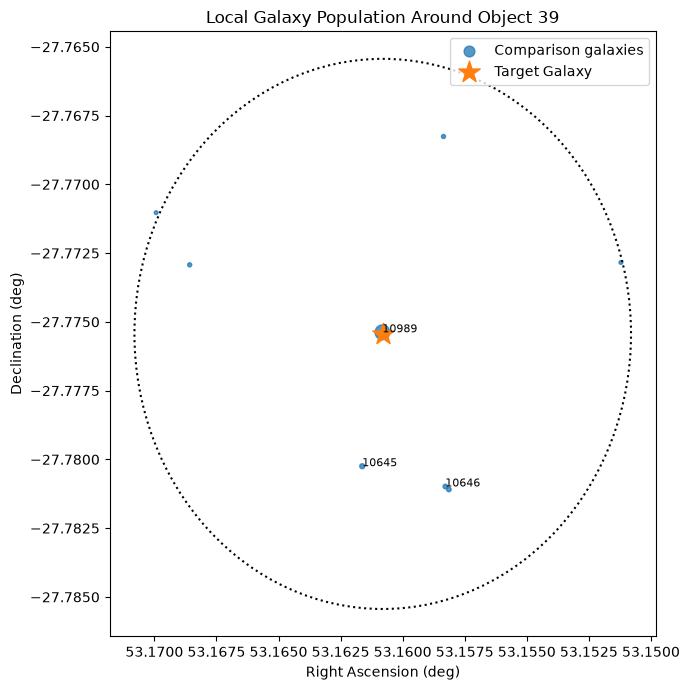

In [13]:
# ==========================================
# Cell 12 — Sky Map (Improved)
# ==========================================

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

fig, ax = plt.subplots(figsize=(7,7))

# Marker size inversely proportional to separation
sizes = 250 / (comparison_catalog["sep_arcsec"] + 2)

ax.scatter(
    comparison_catalog["RAJ2000"],
    comparison_catalog["DEJ2000"],
    s=sizes,
    alpha=0.75,
    label="Comparison galaxies"
)

# Label three nearest neighbours
nearest = comparison_catalog[:3]

for row in nearest:
    ax.text(
        row["RAJ2000"],
        row["DEJ2000"],
        str(row["Seq"]),
        fontsize=8
    )

# Target
ax.scatter(
    target_ra,
    target_dec,
    marker="*",
    s=260,
    label="Target Galaxy"
)

# 36 arcsec search radius
radius_deg = 36 / 3600

circle = Circle(
    (target_ra, target_dec),
    radius_deg,
    fill=False,
    linestyle=":",
    linewidth=1.5
)

ax.add_patch(circle)

ax.invert_xaxis()

ax.set_xlabel("Right Ascension (deg)")
ax.set_ylabel("Declination (deg)")
ax.set_title("Local Galaxy Population Around Object 39")

ax.legend()

plt.tight_layout()
plt.show()

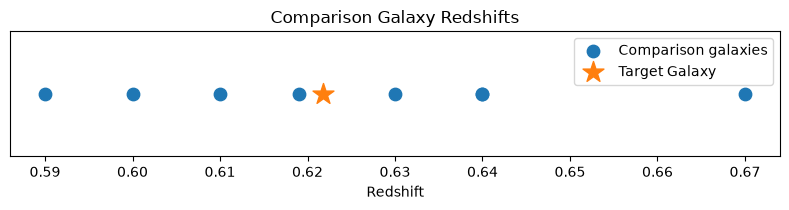

In [14]:
# ==========================================
# Cell 13 — Redshift Distribution
# ==========================================

plt.figure(figsize=(8,2.2))

y = np.zeros(len(comparison_catalog))

plt.scatter(
    comparison_catalog["best_z"],
    y,
    s=80,
    label="Comparison galaxies"
)

plt.scatter(
    target_z,
    0,
    marker="*",
    s=250,
    label="Target Galaxy"
)

plt.yticks([])

plt.xlabel("Redshift")
plt.title("Comparison Galaxy Redshifts")

plt.legend()

plt.tight_layout()
plt.show()

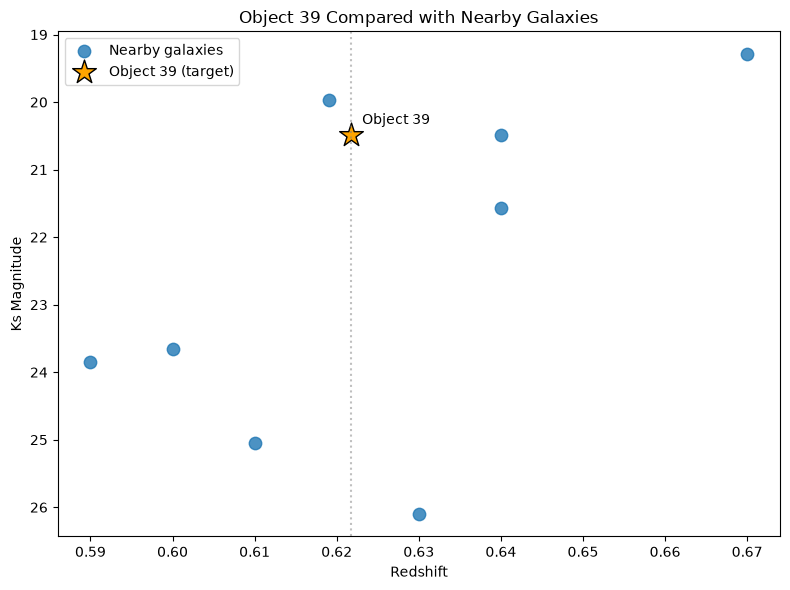

In [15]:
# ==========================================
# Cell 15 — Ks Magnitude vs. Redshift
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Keep only galaxies with valid Ks magnitudes
mask = ~comparison_catalog["Ksmag"].mask

plt.figure(figsize=(8, 6))

# Comparison galaxies
plt.scatter(
    comparison_catalog["best_z"][mask],
    comparison_catalog["Ksmag"][mask],
    s=80,
    alpha=0.8,
    label="Nearby galaxies"
)

# Object 39
plt.scatter(
    target_z,
    target_photometry["Ksmag"],
    marker="*",
    s=320,
    color="orange",
    edgecolor="black",
    linewidth=1,
    label="Object 39 (target)"
)

# Annotate target
plt.annotate(
    "Object 39",
    (target_z, target_photometry["Ksmag"]),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10
)

# Guide line at the target redshift
plt.axvline(
    target_z,
    color="gray",
    linestyle=":",
    alpha=0.5
)

# Astronomical convention:
# brighter magnitudes are smaller numbers
plt.gca().invert_yaxis()

plt.xlabel("Redshift")
plt.ylabel("Ks Magnitude")
plt.title("Object 39 Compared with Nearby Galaxies")

plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# Cell 16 — Einstein Scientific Summary
# ==========================================

print("=" * 70)
print("Einstein Scientific Assessment")
print("=" * 70)

print(f"""
Target Galaxy
-------------
Name                : {target_name}
Einstein Label      : {target_id}
GOODS-MUSIC Seq     : {target_goods['Seq']}

Target Redshift
---------------
Einstein Catalog    : {target_z:.6f}
GOODS-MUSIC (photo) : {target_goods['zphot']:.3f}

Angular Separation
------------------
Nearest GOODS-MUSIC counterpart:
    {separations[closest].arcsec:.3f} arcsec

Infrared Photometry
-------------------
J     : {target_photometry['Jmag']:.3f}
H     : {target_photometry['Hmag']:.3f}
Ks    : {target_photometry['Ksmag']:.3f}
IR3.6 : {target_photometry['IR36mag']:.3f}
IR4.5 : {target_photometry['IR45mag']:.3f}

Comparison Sample
-----------------
Nearby galaxies analysed : {len(comparison_catalog)}
Redshift interval         : ±{delta_z:.3f}
Search radius             : {radius*3600:.0f} arcsec
""")

print("=" * 70)
print("Interpretation")
print("=" * 70)

print(f"""
Object 39 was successfully cross-matched with GOODS-MUSIC source
{target_goods['Seq']} at an angular separation of only
{separations[closest].arcsec:.3f} arcseconds, indicating a highly
reliable positional association.

The target lies within a comparison sample of
{len(comparison_catalog)} nearby galaxies having redshifts within
±{delta_z:.3f} of the Einstein catalog value.

Its Ks-band magnitude ({target_photometry['Ksmag']:.3f}) places
Object 39 near the middle of the local infrared luminosity
distribution. It is neither exceptionally bright nor unusually faint
relative to neighbouring galaxies.

The comparison sample contains no objects flagged as active galactic
nuclei (AGN), suggesting that the immediate environment is dominated
by normal galaxies.

Overall, the evidence indicates that Object 39 is representative of
its local galaxy population rather than an obvious outlier. The very
small positional offset between the Einstein and GOODS-MUSIC catalogs
provides confidence in the cross-identification and establishes a
strong foundation for future analyses of its environment and physical
properties.
""")

Einstein Scientific Assessment

Target Galaxy
-------------
Name                : EIS J033238.61-274631.6
Einstein Label      : 39
GOODS-MUSIC Seq     : 10989

Target Redshift
---------------
Einstein Catalog    : 0.621743
GOODS-MUSIC (photo) : 0.640

Angular Separation
------------------
Nearest GOODS-MUSIC counterpart:
    0.215 arcsec

Infrared Photometry
-------------------
J     : 21.075
H     : 20.730
Ks    : 20.489
IR3.6 : 20.838
IR4.5 : 21.232

Comparison Sample
-----------------
Nearby galaxies analysed : 8
Redshift interval         : ±0.050
Search radius             : 36 arcsec

Interpretation

Object 39 was successfully cross-matched with GOODS-MUSIC source
10989 at an angular separation of only
0.215 arcseconds, indicating a highly
reliable positional association.

The target lies within a comparison sample of
8 nearby galaxies having redshifts within
±0.050 of the Einstein catalog value.

Its Ks-band magnitude (20.489) places
Object 39 near the middle of the local infrared

### Infrared Photometry

Infrared photometry provides important information about the stellar population and dust content of Einstein Object 39 (EIS J033238.61−274631.6). Unlike optical observations, infrared wavelengths are less affected by interstellar dust and are particularly sensitive to the older stellar populations that contain most of a galaxy's stellar mass. When combined with optical, ultraviolet, X-ray, and millimetre observations, these measurements contribute to a more complete understanding of the galaxy's physical properties.

The available infrared measurements are:

| Band | Wavelength | Apparent Magnitude |
|------|------------|-------------------:|
| J | 1.25 μm | 21.075 |
| H | 1.65 μm | 20.730 |
| Ks | 2.16 μm | 20.489 |
| IR3.6 | 3.6 μm | 20.838 |
| IR4.5 | 4.5 μm | 21.232 |

The galaxy exhibits a relatively smooth infrared spectral energy distribution, with apparent magnitudes ranging from approximately 20.5 to 21.2 across the near- and mid-infrared bands. The brightest measurement occurs in the **Ks** band (2.16 μm), which is commonly used as a tracer of a galaxy's stellar mass because it is only weakly affected by dust extinction.

Overall, the infrared photometry is consistent with a moderately distant galaxy (redshift *z* ≈ 0.62) whose emission is dominated by its stellar population. No unusually strong infrared excess is evident from these measurements alone, suggesting that the galaxy does not exhibit exceptionally bright warm dust emission at these wavelengths. Combined with observations from HST, JWST, ALMA, and other astronomical surveys, these infrared data contribute to a comprehensive multi-wavelength characterization of Einstein Object 39.

In [ ]:
# ============================================================
# Notebook Status
# ============================================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 21_comparative_galaxy_analysis.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))